In [ ]:
! pip install qiskit
! pip install matplotlib
! pip install pylatexenc
! pip install scipy
! pip install numpy
! pip install qiskit_aer
! pip install qiskit_algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 20.4 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 40.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 34.8 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [qiskit]2m6/7 [qiskit]


Quantum Circuit:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 

Circuit diagram:


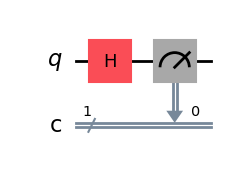

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# Create a quantum circuit with 1 qubit
qc = QuantumCircuit(1, 1, name='Hadamard Gate Circuit')

# Apply Hadamard gate to the qubit
qc.h(0)

# Measure the qubit
qc.measure(0, 0)

# Display the circuit
print("Quantum Circuit:")
print(qc)
print("\nCircuit diagram:")
qc.draw(output='mpl')


Simulation Results (1000 shots):
{'0': 500, '1': 500}

Probability of measuring |0⟩: 50.0%
Probability of measuring |1⟩: 50.0%


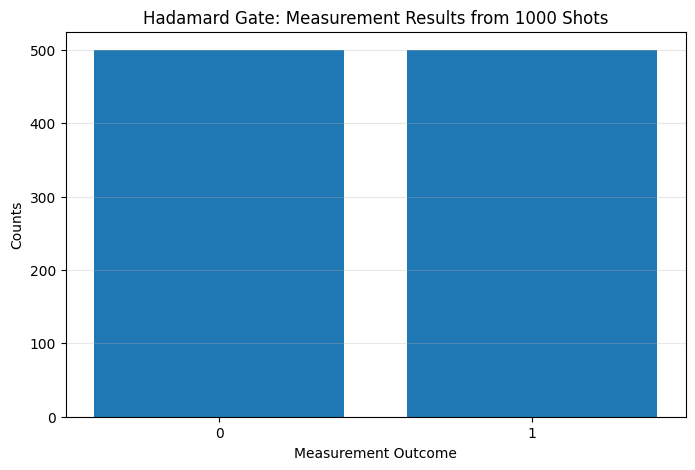

In [3]:
# Simulate the circuit
simulator = AerSimulator()
job = simulator.run(qc, shots=1000)
result = job.result()
counts = result.get_counts(qc)

print("\nSimulation Results (1000 shots):")
print(counts)
print(f"\nProbability of measuring |0⟩: {counts.get('0', 0)/1000:.1%}")
print(f"Probability of measuring |1⟩: {counts.get('1', 0)/1000:.1%}")

# Plot the results
plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values())
plt.xlabel('Measurement Outcome')
plt.ylabel('Counts')
plt.title('Hadamard Gate: Measurement Results from 1000 Shots')
plt.grid(axis='y', alpha=0.3)
plt.show()

## How the Hadamard Gate Works

### What is a Hadamard Gate?
The Hadamard gate (H gate) is one of the most fundamental quantum gates. It creates a **superposition** of quantum states.

### Mathematical Representation
The Hadamard gate matrix is:
$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

### How It Transforms States
- **Starting state**: A qubit in the |0⟩ state (deterministic)
- **After H gate**: The qubit enters a superposition: $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
- **Measurement result**: 50% probability of measuring |0⟩, 50% probability of measuring |1⟩

### Key Properties
1. **Creates Superposition**: Converts a definite state into a probabilistic mixture
2. **Equal Probability**: Results in equal superposition of |0⟩ and |1⟩
3. **Reversible**: Applying H twice returns the original state (H² = I)
4. **Universal**: Essential building block for most quantum algorithms

### Why It's Important
The Hadamard gate is crucial for:
- Quantum superposition (a key advantage of quantum computing)
- Quantum algorithms like Grover's search and Shor's algorithm
- Creating uniform probability distributions over quantum states

Multi-Qubit Quantum Circuit (3 qubits, 2 classical bits):
        ┌───┐        ┌─┐   
q_0: ───┤ H ├─────■──┤M├───
        ├───┤   ┌─┴─┐└╥┘┌─┐
q_1: ───┤ X ├───┤ X ├─╫─┤M├
     ┌──┴───┴──┐└───┘ ║ └╥┘
q_2: ┤ Ry(0.5) ├──────╫──╫─
     └─────────┘      ║  ║ 
c: 2/═════════════════╩══╩═
                      0  1 

Circuit diagram:


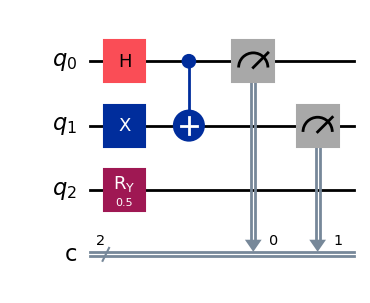

In [6]:
# Create a quantum circuit with 3 qubits and 2 classical bits
qc_multi = QuantumCircuit(3, 2, name='Multi-Qubit Circuit')

# Apply different gates to each qubit
qc_multi.h(0)      # Hadamard on qubit 0
qc_multi.x(1)      # Pauli-X (NOT) on qubit 1
qc_multi.ry(0.5, 2)  # Rotation around Y-axis on qubit 2

# Add some entanglement with CNOT gates
qc_multi.cx(0, 1)  # CNOT with control on qubit 0, target on qubit 1

# Measure only qubits 0 and 1 into classical bits 0 and 1
qc_multi.measure([0, 1], [0, 1])

# Display the circuit
print("Multi-Qubit Quantum Circuit (3 qubits, 2 classical bits):")
print(qc_multi)
print("\nCircuit diagram:")
qc_multi.draw(output='mpl')


Simulation Results (1000 shots):
Measurement Outcomes (classical bits 0 and 1):
  01: 489 times (48.9%)
  10: 511 times (51.1%)


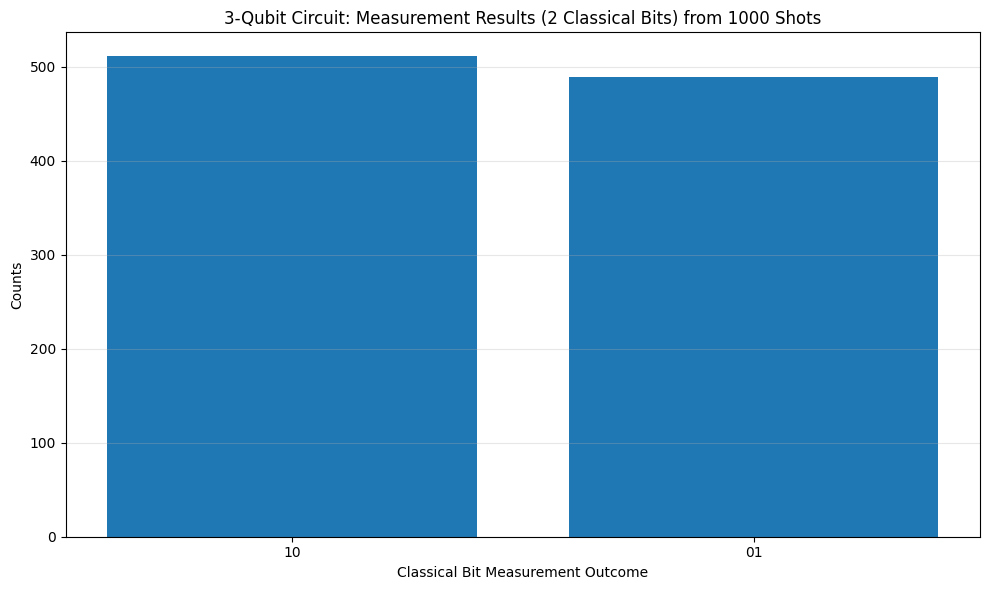

In [7]:
# Simulate the multi-qubit circuit
job_multi = simulator.run(qc_multi, shots=1000)
result_multi = job_multi.result()
counts_multi = result_multi.get_counts(qc_multi)

print("\nSimulation Results (1000 shots):")
print("Measurement Outcomes (classical bits 0 and 1):")
for outcome, count in sorted(counts_multi.items()):
    print(f"  {outcome}: {count} times ({count/1000:.1%})")

# Plot the results
plt.figure(figsize=(10, 6))
plt.bar(range(len(counts_multi)), list(counts_multi.values()))
plt.xticks(range(len(counts_multi)), list(counts_multi.keys()))
plt.xlabel('Classical Bit Measurement Outcome')
plt.ylabel('Counts')
plt.title('3-Qubit Circuit: Measurement Results (2 Classical Bits) from 1000 Shots')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Quantum Gates Reference Guide

## Overview
Quantum gates are the building blocks of quantum circuits. Each gate performs a specific transformation on quantum states. Here we'll explore the most commonly used gates with examples and visualizations.

### Single-Qubit Gates

#### 1. Pauli-X Gate (NOT Gate)
**What it does**: Flips the quantum state (|0⟩ → |1⟩, |1⟩ → |0⟩)

**Matrix**:
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

#### 2. Pauli-Y Gate
**What it does**: Rotates around the Y-axis by π radians, applies a phase flip

**Matrix**:
$$Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$$

#### 3. Pauli-Z Gate
**What it does**: Applies a phase flip to |1⟩ without changing |0⟩

**Matrix**:
$$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

#### 4. Hadamard Gate
**What it does**: Creates equal superposition of |0⟩ and |1⟩

**Matrix**:
$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

#### 5. S Gate (Phase Gate)
**What it does**: Applies a π/2 phase gate to |1⟩

**Matrix**:
$$S = \begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}$$

#### 6. T Gate
**What it does**: Applies a π/4 phase gate to |1⟩

**Matrix**:
$$T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}$$

### Multi-Qubit Gates

#### 7. CNOT Gate (Controlled-X)
**What it does**: Flips the target qubit if the control qubit is |1⟩

#### 8. SWAP Gate
**What it does**: Exchanges the states of two qubits

#### 9. Toffoli Gate (Controlled-Controlled-X)
**What it does**: Flips the target qubit if both control qubits are |1⟩

In [ ]:
# Example 1: Pauli-X Gate (NOT Gate)
print("="*60)
print("EXAMPLE 1: PAULI-X GATE (NOT GATE)")
print("="*60)

qc_x = QuantumCircuit(1, 1, name='X Gate')
qc_x.x(0)  # Apply X gate
qc_x.measure(0, 0)

print("\nCircuit with X gate:")
print(qc_x)

job_x = simulator.run(qc_x, shots=1000)
counts_x = job_x.result().get_counts(qc_x)
print(f"\nResults: {counts_x}")
print("Explanation: X gate flips |0⟩ to |1⟩, so we measure |1⟩ with 100% probability")

In [ ]:
# Example 2: Pauli-Y Gate
print("\n" + "="*60)
print("EXAMPLE 2: PAULI-Y GATE")
print("="*60)

qc_y = QuantumCircuit(1, 1, name='Y Gate')
qc_y.h(0)  # Create superposition first
qc_y.y(0)  # Apply Y gate
qc_y.measure(0, 0)

print("\nCircuit with H and Y gates:")
print(qc_y)

job_y = simulator.run(qc_y, shots=1000)
counts_y = job_y.result().get_counts(qc_y)
print(f"\nResults: {counts_y}")
print("Explanation: Y gate rotates around the Y-axis. Applied after H gate,")
print("it creates a different superposition state.")

In [ ]:
# Example 3: Pauli-Z Gate
print("\n" + "="*60)
print("EXAMPLE 3: PAULI-Z GATE")
print("="*60)

qc_z = QuantumCircuit(1, 1, name='Z Gate')
qc_z.h(0)  # Create superposition
qc_z.z(0)  # Apply Z gate (phase flip)
qc_z.measure(0, 0)

print("\nCircuit with H and Z gates:")
print(qc_z)

job_z = simulator.run(qc_z, shots=1000)
counts_z = job_z.result().get_counts(qc_z)
print(f"\nResults: {counts_z}")
print("Explanation: Z gate applies a phase flip to |1⟩. It doesn't change")
print("measurement probabilities for |0⟩ and |1⟩, but affects interference patterns.")
print(f"Approximately 50/50 split between |0⟩ and |1⟩ (phase doesn't affect single-qubit measurement)")

In [ ]:
# Example 4: S Gate (Phase Gate)
print("\n" + "="*60)
print("EXAMPLE 4: S GATE (PHASE GATE)")
print("="*60)

qc_s = QuantumCircuit(1, 1, name='S Gate')
qc_s.h(0)  # Create superposition
qc_s.s(0)  # Apply S gate (π/2 phase)
qc_s.measure(0, 0)

print("\nCircuit with H and S gates:")
print(qc_s)

job_s = simulator.run(qc_s, shots=1000)
counts_s = job_s.result().get_counts(qc_s)
print(f"\nResults: {counts_s}")
print("Explanation: S gate applies a π/2 phase to |1⟩. Like Z gate,")
print("it doesn't change measurement probabilities but affects quantum interference.")

In [ ]:
# Example 5: T Gate
print("\n" + "="*60)
print("EXAMPLE 5: T GATE")
print("="*60)

qc_t = QuantumCircuit(1, 1, name='T Gate')
qc_t.h(0)  # Create superposition
qc_t.t(0)  # Apply T gate (π/4 phase)
qc_t.measure(0, 0)

print("\nCircuit with H and T gates:")
print(qc_t)

job_t = simulator.run(qc_t, shots=1000)
counts_t = job_t.result().get_counts(qc_t)
print(f"\nResults: {counts_t}")
print("Explanation: T gate applies a π/4 phase to |1⟩. Smaller phase than S gate.")
print("Still preserves measurement probabilities but useful for quantum algorithms.")

In [ ]:
# Example 6: RX Gate (Rotation around X-axis)
print("\n" + "="*60)
print("EXAMPLE 6: RX GATE (ROTATION AROUND X-AXIS)")
print("="*60)

qc_rx = QuantumCircuit(1, 1, name='RX Gate')
qc_rx.rx(3.14159/2, 0)  # Rotate by π/2 radians
qc_rx.measure(0, 0)

print("\nCircuit with RX(π/2) gate:")
print(qc_rx)

job_rx = simulator.run(qc_rx, shots=1000)
counts_rx = job_rx.result().get_counts(qc_rx)
print(f"\nResults: {counts_rx}")
print("Explanation: RX gate rotates the qubit around the X-axis by a specified angle.")
print("RX(π/2) creates a superposition similar to Hadamard but with phase relationships.")

In [ ]:
# Example 7: RY Gate (Rotation around Y-axis)
print("\n" + "="*60)
print("EXAMPLE 7: RY GATE (ROTATION AROUND Y-AXIS)")
print("="*60)

qc_ry = QuantumCircuit(1, 1, name='RY Gate')
qc_ry.ry(3.14159/4, 0)  # Rotate by π/4 radians
qc_ry.measure(0, 0)

print("\nCircuit with RY(π/4) gate:")
print(qc_ry)

job_ry = simulator.run(qc_ry, shots=1000)
counts_ry = job_ry.result().get_counts(qc_ry)
print(f"\nResults: {counts_ry}")
print("Explanation: RY gate rotates around the Y-axis by a specified angle.")
print("RY(π/4) creates a superposition weighted more towards |0⟩ than |1⟩.")

In [ ]:
# Example 8: CNOT Gate (Controlled-X)
print("\n" + "="*60)
print("EXAMPLE 8: CNOT GATE (CONTROLLED-X)")
print("="*60)

qc_cnot = QuantumCircuit(2, 2, name='CNOT Gate')
qc_cnot.h(0)      # Control qubit in superposition
qc_cnot.cx(0, 1)  # CNOT: if qubit 0 is |1⟩, flip qubit 1
qc_cnot.measure([0, 1], [0, 1])

print("\nCircuit with H and CNOT gates:")
print(qc_cnot)

job_cnot = simulator.run(qc_cnot, shots=1000)
counts_cnot = job_cnot.result().get_counts(qc_cnot)
print(f"\nResults: {counts_cnot}")
print("Explanation: CNOT gate creates entanglement between two qubits.")
print("If control qubit (0) is |1⟩, it flips the target qubit (1).")
print("Results show entanglement: |00⟩ and |11⟩ with ~50% each.")

In [ ]:
# Example 9: SWAP Gate
print("\n" + "="*60)
print("EXAMPLE 9: SWAP GATE")
print("="*60)

qc_swap = QuantumCircuit(2, 2, name='SWAP Gate')
qc_swap.x(0)       # Set qubit 0 to |1⟩
qc_swap.h(1)       # Set qubit 1 to superposition
qc_swap.swap(0, 1) # Swap the states
qc_swap.measure([0, 1], [0, 1])

print("\nCircuit with X, H, and SWAP gates:")
print(qc_swap)

job_swap = simulator.run(qc_swap, shots=1000)
counts_swap = job_swap.result().get_counts(qc_swap)
print(f"\nResults: {counts_swap}")
print("Explanation: SWAP gate exchanges the states of two qubits.")
print("Before SWAP: q0=|1⟩, q1=superposition")
print("After SWAP: q0=superposition, q1=|1⟩")

In [ ]:
# Example 10: Toffoli Gate (Controlled-Controlled-X)
print("\n" + "="*60)
print("EXAMPLE 10: TOFFOLI GATE (CONTROLLED-CONTROLLED-X)")
print("="*60)

qc_toffoli = QuantumCircuit(3, 3, name='Toffoli Gate')
qc_toffoli.x(0)           # Set control qubit 0 to |1⟩
qc_toffoli.x(1)           # Set control qubit 1 to |1⟩
qc_toffoli.ccx(0, 1, 2)   # Toffoli: flip target if both controls are |1⟩
qc_toffoli.measure([0, 1, 2], [0, 1, 2])

print("\nCircuit with Toffoli gate:")
print(qc_toffoli)

job_toffoli = simulator.run(qc_toffoli, shots=1000)
counts_toffoli = job_toffoli.result().get_counts(qc_toffoli)
print(f"\nResults: {counts_toffoli}")
print("Explanation: Toffoli gate is a 3-qubit gate.")
print("It flips the target qubit only if BOTH control qubits are |1⟩.")
print("Since both controls are |1⟩, target (|0⟩) gets flipped to |1⟩.")
print("Result: |111⟩ with 100% probability")

## Summary of Quantum Gates

| Gate | Type | Purpose | Key Property |
|------|------|---------|--------------|
| **X (Pauli-X)** | Single-qubit | Bit flip | Flips \|0⟩ ↔ \|1⟩ |
| **Y (Pauli-Y)** | Single-qubit | Bit flip + phase | Rotates around Y-axis |
| **Z (Pauli-Z)** | Single-qubit | Phase flip | Applies phase to \|1⟩ |
| **H (Hadamard)** | Single-qubit | Superposition | Creates 50/50 superposition |
| **S (Phase)** | Single-qubit | Phase gate | π/2 phase to \|1⟩ |
| **T** | Single-qubit | Phase gate | π/4 phase to \|1⟩ |
| **RX(θ)** | Single-qubit | Rotation | Rotates around X-axis by θ |
| **RY(θ)** | Single-qubit | Rotation | Rotates around Y-axis by θ |
| **RZ(θ)** | Single-qubit | Rotation | Rotates around Z-axis by θ |
| **CNOT** | Two-qubit | Entanglement | Controlled X gate |
| **SWAP** | Two-qubit | Exchange | Swaps qubit states |
| **Toffoli** | Three-qubit | Controlled-Controlled-X | AND-like operation |

## Key Concepts

**Superposition**: A quantum state that is a combination of multiple basis states (e.g., both |0⟩ and |1⟩)

**Entanglement**: When two or more qubits are correlated such that the state of one depends on the other

**Phase**: The complex amplitude associated with a quantum state, important for quantum interference

**Measurement**: Collapses the quantum state to either |0⟩ or |1⟩ with probabilities determined by the superposition

# Understanding Measurement in Quantum Computing

## What Does Measurement Do?

Measurement is the process of extracting classical information from a quantum system. When you measure a qubit, you collapse its quantum state into a definite classical value: either |0⟩ or |1⟩.

### The Quantum-to-Classical Bridge

**Before Measurement**: A qubit can exist in a superposition:
$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$

where α and β are complex amplitudes satisfying |α|² + |β|² = 1.

**After Measurement**: The qubit collapses to either |0⟩ or |1⟩ with probabilities:
- Probability of measuring |0⟩ = |α|²
- Probability of measuring |1⟩ = |β|²

### Key Point: Wavefunction Collapse
Once measured, the qubit **cannot return to superposition**. The measurement irreversibly collapses the quantum state to a classical value.

## Why Is Measurement Required?

### 1. **Extracting Results**
Quantum computers process information, but we need to extract the results as classical bits to read them from classical computers.

### 2. **Getting Classical Output**
Without measurement, quantum states remain abstract mathematical objects. Measurement converts quantum information into readable classical bits (0 or 1).

### 3. **Verifying Quantum Algorithms**
To validate that a quantum algorithm works, we measure the output qubits multiple times and analyze the probability distribution.

### 4. **Classical-Quantum Interface**
Measurement is the interface between the quantum world and the classical world where we operate our computers.

## How Does Measurement Impact Quantum Circuits?

### 1. **State Collapse**
Measurement destroys the quantum superposition. You cannot use a measured qubit in further quantum operations with its previous superposition state.

### 2. **Probabilistic Results**
Multiple measurements of identically prepared qubits will give different results, following the probability distribution defined by the superposition.

### 3. **Information Loss**
Measurement extracts limited information. A single measurement of a qubit gives only 1 bit of information (0 or 1), even though the quantum state encodes continuous probability amplitudes.

### 4. **Circuit Design Consideration**
You must measure at the END of quantum operations. Measuring in the middle of a circuit will destroy superposition and interfere with subsequent quantum gates.

### 5. **Statistical Nature**
To understand the full output distribution, you typically run a circuit many times (shots) and measure each time. This is why simulators use "shots" (e.g., 1000 shots = run 1000 times).

In [ ]:
# Demonstration: Impact of Measurement

print("="*70)
print("DEMONSTRATION: IMPACT OF MEASUREMENT")
print("="*70)

# Scenario 1: Measuring immediately after H gate
print("\n" + "="*70)
print("SCENARIO 1: Measure After Hadamard (Correct Approach)")
print("="*70)

qc_measure_correct = QuantumCircuit(1, 1, name='Measure After H')
qc_measure_correct.h(0)        # Create superposition
qc_measure_correct.measure(0, 0)  # Measure at the end

print("\nCircuit: H gate → Measure")
print(qc_measure_correct)

job_correct = simulator.run(qc_measure_correct, shots=1000)
counts_correct = job_correct.result().get_counts(qc_measure_correct)
print(f"\nResults from 1000 shots:")
print(f"  |0⟩: {counts_correct.get('0', 0)} times ({counts_correct.get('0', 0)/1000:.1%})")
print(f"  |1⟩: {counts_correct.get('1', 0)} times ({counts_correct.get('1', 0)/1000:.1%})")
print("\n✓ Expected: ~50% |0⟩, ~50% |1⟩ due to superposition")

In [ ]:
# Scenario 2: Demonstrating collapse - measuring a fixed state
print("\n" + "="*70)
print("SCENARIO 2: Measure X Gate (State Already Determined)")
print("="*70)

qc_collapse_x = QuantumCircuit(1, 1, name='Measure After X')
qc_collapse_x.x(0)            # X gate: |0⟩ → |1⟩ (deterministic)
qc_collapse_x.measure(0, 0)   # Measure the result

print("\nCircuit: X gate → Measure")
print(qc_collapse_x)

job_collapse_x = simulator.run(qc_collapse_x, shots=1000)
counts_collapse_x = job_collapse_x.result().get_counts(qc_collapse_x)
print(f"\nResults from 1000 shots:")
print(f"  |0⟩: {counts_collapse_x.get('0', 0)} times ({counts_collapse_x.get('0', 0)/1000:.1%})")
print(f"  |1⟩: {counts_collapse_x.get('1', 0)} times ({counts_collapse_x.get('1', 0)/1000:.1%})")
print("\n✓ Expected: 100% |1⟩ because X gate flips |0⟩ to |1⟩ (deterministic state)")

In [ ]:
# Scenario 3: Impact of measurement on subsequent operations
print("\n" + "="*70)
print("SCENARIO 3: Measurement Destroys Superposition")
print("="*70)

# Create superposition with multiple H gates to show effect
qc_h_h = QuantumCircuit(1, 1, name='H-H Circuit')
qc_h_h.h(0)        # Creates |+⟩ = (|0⟩ + |1⟩)/√2
qc_h_h.h(0)        # H² = I, returns to |0⟩
qc_h_h.measure(0, 0)

print("\nCircuit: H → H → Measure")
print(qc_h_h)

job_h_h = simulator.run(qc_h_h, shots=1000)
counts_h_h = job_h_h.result().get_counts(qc_h_h)
print(f"\nResults from 1000 shots:")
print(f"  |0⟩: {counts_h_h.get('0', 0)} times ({counts_h_h.get('0', 0)/1000:.1%})")
print(f"  |1⟩: {counts_h_h.get('1', 0)} times ({counts_h_h.get('1', 0)/1000:.1%})")
print("\n✓ Expected: 100% |0⟩ because H gate applied twice cancels out")
print("  (returns to original state)")
print("\nKey insight: Quantum interference works when gates act on superposition.")

In [ ]:
# Scenario 4: Comparing with vs without mid-circuit measurement
print("\n" + "="*70)
print("SCENARIO 4: Effect of Measuring Mid-Circuit vs At End")
print("="*70)

# Without measurement in middle - quantum interference works
qc_no_mid_measure = QuantumCircuit(1, 1, name='H-H No Mid Measure')
qc_no_mid_measure.h(0)
# NO measurement here - superposition preserved
qc_no_mid_measure.h(0)  # This H gate interferes with previous H
qc_no_mid_measure.measure(0, 0)

print("\nCircuit A: H → H → Measure (Quantum interference works)")
print(qc_no_mid_measure)

job_no_mid = simulator.run(qc_no_mid_measure, shots=1000)
counts_no_mid = job_no_mid.result().get_counts(qc_no_mid_measure)
print(f"\nResults from 1000 shots:")
print(f"  |0⟩: {counts_no_mid.get('0', 0)/1000:.1%}")
print(f"  |1⟩: {counts_no_mid.get('1', 0)/1000:.1%}")
print("✓ Result: 100% |0⟩ (quantum interference)")

# With measurement in the middle - interference is lost
qc_mid_measure = QuantumCircuit(2, 2, name='H-Measure-H-Measure')
qc_mid_measure.h(0)
qc_mid_measure.measure(0, 0)  # MEASURE mid-circuit - collapses superposition
qc_mid_measure.h(1)           # Apply H to a fresh qubit
qc_mid_measure.measure(1, 1)

print("\n" + "-"*70)
print("\nCircuit B: H → Measure → (fresh qubit) → H → Measure")
print(qc_mid_measure)

job_mid = simulator.run(qc_mid_measure, shots=1000)
counts_mid = job_mid.result().get_counts(qc_mid_measure)
print(f"\nResults from 1000 shots (showing first bit only):")
first_bit_counts = {}
for outcome, count in counts_mid.items():
    first_bit = outcome[0]  # First classical bit from first measurement
    first_bit_counts[first_bit] = first_bit_counts.get(first_bit, 0) + count

print(f"  First qubit measured:")
print(f"    |0⟩: {first_bit_counts.get('0', 0)/1000:.1%}")
print(f"    |1⟩: {first_bit_counts.get('1', 0)/1000:.1%}")
print("✓ Result: ~50% |0⟩, ~50% |1⟩ (random, not deterministic)")

## Summary: Measurement's Role

| Aspect | Description |
|--------|-------------|
| **What** | Collapses quantum superposition to classical bit (0 or 1) |
| **Why** | Bridge between quantum world and classical world; extract results |
| **When** | Typically at the END of quantum circuit |
| **Impact** | Destroys superposition; results probabilistic; limited information extracted |
| **Key Rule** | Don't measure in the middle unless you intend to discard quantum information |

## Real-World Analogy

Think of a qubit in superposition like a spinning coin in mid-air:
- **Before measurement**: Coin is spinning (both heads AND tails)
- **Measurement**: Catch the coin (it lands on heads OR tails)
- **After measurement**: Coin shows one face; spinning is over

You can't know which face until you catch it. And once caught, you can't make it spin again without flipping it anew.

## Important Notes for Quantum Programming

1. **Always measure at the end** of a quantum computation to get results
2. **Avoid mid-circuit measurements** unless specifically needed for conditional logic
3. **Use many shots** to build accurate probability distributions
4. **Phase information is hidden**: Measurement only reveals probabilities, not phase relationships
5. **Measurement is irreversible**: Once measured, the quantum state cannot be recovered

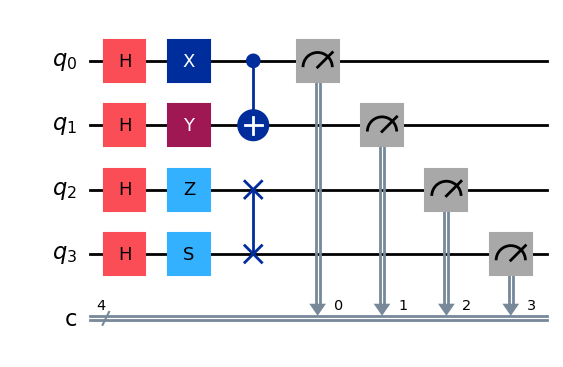

In [9]:
# Example: 4 Qubits and 4 Classical Bits Measurement
from qiskit import QuantumCircuit

qc_4q_4c = QuantumCircuit(4, 4, name='4 Qubits 4 Classical Bits')

# Apply Hadamard gate to all qubits to create superposition
qc_4q_4c.h([0, 1, 2, 3])

# Add a layer of gates
qc_4q_4c.x(0)         # Pauli-X on qubit 0
qc_4q_4c.y(1)         # Pauli-Y on qubit 1
qc_4q_4c.z(2)         # Pauli-Z on qubit 2
qc_4q_4c.s(3)         # S gate (phase) on qubit 3
qc_4q_4c.cx(0, 1)     # CNOT: control 0, target 1
qc_4q_4c.swap(2, 3)   # SWAP between qubits 2 and 3

# Measure each qubit into its corresponding classical bit
qc_4q_4c.measure([0, 1, 2, 3], [0, 1, 2, 3])

# Draw the circuit using matplotlib
qc_4q_4c.draw(output='mpl')

# Example: Demonstrating Phase with Z Gate
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc_phase = QuantumCircuit(1, 1)
qc_phase.h(0)      # Create superposition: (|0⟩ + |1⟩)/√2
qc_phase.z(0)      # Apply Z gate: flips phase of |1⟩
qc_phase.measure(0, 0)

simulator = AerSimulator()
job = simulator.run(qc_phase, shots=1000)
counts = job.result().get_counts(qc_phase)

print("Measurement results after Z gate phase flip:", counts)
plt.bar(counts.keys(), counts.values())
plt.xlabel('Measurement Outcome')
plt.ylabel('Counts')
plt.title('Phase Flip with Z Gate')
plt.show()